# Sendo a base apresentada no arquivo abaixo:
- https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_customers_dataset.csv
    - Já disponível no banco de dados `vendas_db.db` através do link:
        - https://drive.google.com/file/d/1eONzrbEu5BoijDRj56gjL_2Ik5qxtR6U/view?usp=sharing
<br><br>
- Sua tarefa é ajudar a área de negócios a **montar uma apresentação para a diretoria** para provar a **necessidade de investistimento em uma área de melhoria da experência do cliente ao ter um atraso na entrega**
<br><br>
- Algumas considerações são importantes
    - O **time de logística não considera que o atraso na entrega é um problema relevante** e falou que, em média, as entregas estão sendo feitas 10 dias antes do prazo combinado
    - Não é desejado a previsão de uma entrega atrasada, apenas a **exposição que esse é um problema que pode impactar os clientes**
    - Não queremos uma abordagem de: "nenhuma entrega pode atrasar". Vamos ser mais tranquilos e seguir na linha de: **"uma entrega pode atrasar. Como eu posso melhorar a experiência do cliente caso isso aconteça?"**

In [62]:
import sqlite3 
import pandas as pd

con = sqlite3.connect('../data/vendas_db.db')

cur = con.cursor()

In [63]:
def executa_consulta(consulta):
    resultado = cur.execute(consulta).fetchall()
    resultado = pd.DataFrame(resultado)
    colunas = [i[0] for i in cur.description]
    if resultado.shape[1] > 0:
        resultado.columns = colunas
    print(resultado.shape)
    display(resultado.head(3))
    return resultado

In [64]:
total_pedidos = executa_consulta('SELECT COUNT (*) AS total_pedidos_entregues,\
                 ROUND(AVG(julianday(order_delivered_customer_date) - julianday(order_estimated_delivery_date)), 2) AS media_dias_vs_prazo\
                 FROM orders\
                 WHERE order_status = "delivered"\
                 AND order_delivered_customer_date IS NOT NULL\
                 AND order_estimated_delivery_date IS NOT NULL')

(1, 2)


,total_pedidos_entregues,media_dias_vs_prazo
0,96470,-11.18


### PASSO 1 

“A logística está correta quando olha a média: os pedidos entregues chegaram, em média, 11 dias antes do prazo. Porém, experiência do cliente não acontece na média. Ela acontece pedido a pedido. Por isso, o próximo passo é separar entregas no prazo e entregas atrasadas.”



## Se a média é boa, ainda assim existem clientes impactados por atraso?


In [65]:
status_entrega = executa_consulta('SELECT \
                 CASE \
                     WHEN order_delivered_customer_date > order_estimated_delivery_date \
                         THEN "Atrasado" \
                     ELSE "No prazo ou adiantado" \
                 END AS status_entrega, \
                 COUNT(*) AS qtd_pedidos, \
                 ROUND(100.0 * COUNT(*) / ( \
                     SELECT COUNT(*) \
                     FROM orders \
                     WHERE order_status = "delivered" \
                       AND order_delivered_customer_date IS NOT NULL \
                       AND order_estimated_delivery_date IS NOT NULL \
                 ), 2) AS porcentagem_pedidos \
                 FROM orders \
                 WHERE order_status = "delivered" \
                   AND order_delivered_customer_date IS NOT NULL \
                   AND order_estimated_delivery_date IS NOT NULL \
                 GROUP BY status_entrega')

(2, 3)


,status_entrega,qtd_pedidos,porcentagem_pedidos
0,Atrasado,7826,8.11
1,No prazo ou adiantado,88644,91.89


“A operação realmente funciona bem para a maioria dos clientes: quase 92% dos pedidos chegam no prazo ou antes. Mas ainda temos 7.826 clientes impactados por atraso. A proposta aqui não é dizer que a logística falha como um todo, e sim que existe um grupo relevante de clientes que precisa de uma experiência melhor quando o atraso acontece.”

## Agora que sabemos que o atraso existe, precisamos entender se ele afeta a satisfação do cliente.


In [66]:
satisfacao_entrega = executa_consulta('SELECT CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date\
                 THEN "Atrasado"\
                 ELSE "No prazo ou adiantado"\
                 END AS status_entrega,\
                 COUNT(*) AS qtd_reviews,\
                 ROUND(AVG(r.review_score), 2) AS nota_media,\
                 ROUND(100.0 * AVG(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END), 2) AS percentual_notas_ruins\
                 FROM orders o\
                 JOIN order_reviews r\
                 ON o.order_id = r.order_id\
                 WHERE o.order_status = "delivered"\
                 AND o.order_delivered_customer_date IS NOT NULL\
                 AND o.order_estimated_delivery_date IS NOT NULL\
                 GROUP BY status_entrega')

(2, 4)


,status_entrega,qtd_reviews,nota_media,percentual_notas_ruins
0,Atrasado,7700,2.57,54.03
1,No prazo ou adiantado,88653,4.29,9.23


Aqui está o ponto central da análise: a operação vai bem na média, mas quando o cliente recebe depois do prazo, a experiência muda completamente. A nota média cai de 4,29 para 2,57, e mais da metade dos clientes com atraso dão nota 1 ou 2. Isso mostra que o atraso é um momento crítico da jornada.

## Se o atraso piora tanto a experiência, precisamos entender se todos os atrasos têm o mesmo impacto ou se atrasos maiores são ainda mais críticos.


In [67]:
faixa_atraso = executa_consulta('SELECT CASE\
                 WHEN julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) <= 0\
                    THEN "No prazo ou adiantado"\
                 WHEN julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) BETWEEN 1 AND 3\
                    THEN "Atraso de 1 a 3 dias"\
                 WHEN julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) BETWEEN 4 AND 7\
                    THEN "Atraso de 4 a 7 dias"\
                 ELSE "Atraso acima de 7 dias"\
                    END AS faixa_atraso,\
                 COUNT(*) AS qtd_pedidos,\
                 ROUND(AVG(r.review_score), 2) AS nota_media,\
                 ROUND(100.0 * AVG(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END), 2) AS percentual_notas_ruins\
                 FROM orders o\
                 JOIN order_reviews r\
                 ON o.order_id = r.order_id\
                 WHERE o.order_status = "delivered"\
                 AND o.order_delivered_customer_date IS NOT NULL\
                 AND o.order_estimated_delivery_date IS NOT NULL\
                 GROUP BY faixa_atraso\
                 ORDER BY CASE faixa_atraso\
                 WHEN "No prazo ou adiantado" THEN 1\
                 WHEN "Atraso de 1 a 3 dias" THEN 2\
                 WHEN "Atraso de 4 a 7 dias" THEN 3\
                 ELSE 4\
                 END;')

(4, 4)


,faixa_atraso,qtd_pedidos,nota_media,percentual_notas_ruins
0,No prazo ou adiantado,88653,4.29,9.23
1,Atraso de 1 a 3 dias,1360,3.51,25.51
2,Atraso de 4 a 7 dias,1281,2.17,65.57


O impacto do atraso não é linear. Um atraso pequeno já aumenta o risco de insatisfação, mas atrasos acima de 4 dias entram em uma zona crítica da experiência do cliente. Nessa faixa, mais da metade dos clientes avalia mal a experiência.

A leitura para a apresentação é simples: quanto maior o atraso, maior tende a ser a queda da nota média e o risco de notas 1 ou 2. Por isso, a solução deve priorizar comunicação e tratamento antes que o atraso passe de poucos dias para uma experiência crítica.

In [68]:
status_reviews = executa_consulta('SELECT CASE \
                 WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date \
                 THEN "Atrasado" \
                 ELSE "No prazo ou adiantado" \
                 END AS status_entrega, \
                 COUNT(*) AS qtd_reviews, \
                 SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END) AS qtd_clientes_insatisfeitos, \
                 ROUND(100.0 * SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*), 2) AS porcentagem_insatisfeitos \
                 FROM orders o \
                 JOIN order_reviews r \
                 ON o.order_id = r.order_id \
                 WHERE o.order_status = "delivered" \
                 AND o.order_delivered_customer_date IS NOT NULL \
                 AND o.order_estimated_delivery_date IS NOT NULL \
                 GROUP BY status_entrega')

(2, 4)


,status_entrega,qtd_reviews,qtd_clientes_insatisfeitos,porcentagem_insatisfeitos
0,Atrasado,7700,4160,54.03
1,No prazo ou adiantado,88653,8186,9.23


“O atraso não é o maior volume da operação, mas é um grupo de alto risco. Ele gera mais de 4 mil clientes insatisfeitos e tem uma taxa de insatisfação quase seis vezes maior do que entregas no prazo.”



In [69]:
estado_media = executa_consulta('SELECT c.customer_state AS estado, \
                 COUNT(*) AS qtd_pedidos, \
                 SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) AS qtd_atrasados, \
                 ROUND(100.0 * AVG(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END), 2) AS pct_atraso, \
                 ROUND(AVG(r.review_score), 2) AS nota_media \
                 FROM orders o \
                 JOIN customers c \
                 ON o.customer_id = c.customer_id \
                 JOIN order_reviews r \
                 ON o.order_id = r.order_id \
                 WHERE o.order_status = "delivered" \
                 AND o.order_delivered_customer_date IS NOT NULL \
                 AND o.order_estimated_delivery_date IS NOT NULL \
                 GROUP BY c.customer_state \
                 HAVING COUNT(*) >= 500 \
                 ORDER BY pct_atraso DESC')

(17, 5)


,estado,qtd_pedidos,qtd_atrasados,pct_atraso,nota_media
0,MA,716,137,19.13,3.84
1,CE,1276,195,15.28,3.94
2,BA,3246,447,13.77,3.93


## Problema identificado: atrasos na entrega por estado

A análise mostra que os estados do Maranhão (MA), Ceará (CE) e Bahia (BA) apresentam percentuais relevantes de pedidos atrasados.

O principal ponto de atenção é o Maranhão, que possui o maior percentual de atraso entre os estados analisados: **19,13%** dos pedidos foram entregues após o prazo estimado. Além disso, o estado também apresenta a menor nota média de avaliação, com **3,84**, indicando possível impacto negativo dos atrasos na experiência do cliente.

O Ceará apresenta **15,28%** de pedidos atrasados, porém mantém a maior nota média entre os três estados, com **3,94**. Isso sugere que outros fatores, como qualidade do produto, atendimento ou resolução de problemas, podem estar compensando parcialmente os atrasos.

A Bahia, apesar de concentrar o maior volume de pedidos analisados, com **3.246 pedidos**, possui o menor percentual de atraso, **13,77%**, e uma nota média próxima à do Ceará, com **3,93**. Isso indica uma operação relativamente mais eficiente em comparação aos demais estados.

## Possível causa do problema

O alto percentual de atraso pode estar relacionado a fatores logísticos, como:

- baixa cobertura de transportadoras em determinadas regiões;
- maior distância entre centros de distribuição e clientes;
- rotas de entrega menos eficientes;
- concentração de atrasos em cidades específicas;
- prazos estimados pouco realistas para algumas localidades.

## Recomendação

Recomenda-se priorizar uma investigação logística no estado do Maranhão, pois ele combina o maior percentual de atraso com a menor nota média de avaliação.

As principais ações recomendadas são:

- identificar as cidades do Maranhão com maior volume de atrasos;
- analisar quais transportadoras ou vendedores estão mais associados aos atrasos;
- revisar os prazos estimados de entrega para regiões com recorrência de atraso;
- avaliar a criação de prazos mais realistas para localidades distantes;
- monitorar separadamente a nota média de pedidos atrasados e não atrasados;
- estabelecer indicadores de acompanhamento, como percentual de atraso, tempo médio de atraso e nota média por estado.

## Solução proposta

A solução inicial é criar um monitoramento contínuo dos atrasos por estado e cidade, com foco nos locais que apresentam maior impacto na experiência do cliente.

Para o Maranhão, recomenda-se revisar a operação logística e ajustar os prazos estimados de entrega quando necessário. Caso determinados municípios apresentem atraso recorrente, a empresa pode considerar novas parcerias logísticas, redistribuição de centros de atendimento ou revisão das rotas de entrega.

Com essas ações, espera-se reduzir o percentual de pedidos atrasados, melhorar a previsibilidade das entregas e aumentar a satisfação dos clientes.

In [70]:
categoria_atraso = executa_consulta('SELECT \
                 CASE \
                     WHEN p.product_category_name IS NULL THEN "Categoria não informada" \
                     ELSE p.product_category_name \
                 END AS categoria, \
                 COUNT(*) AS qtd_pedidos, \
                 SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END) AS qtd_atrasados, \
                 ROUND(100.0 * AVG(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1 ELSE 0 END), 2) AS pct_atraso, \
                 ROUND(AVG(r.review_score), 2) AS nota_media \
                 FROM orders o \
                 JOIN order_reviews r \
                 ON o.order_id = r.order_id \
                 JOIN order_items i \
                 ON o.order_id = i.order_id \
                 JOIN products p \
                 ON i.product_id = p.product_id \
                 WHERE o.order_status = "delivered" \
                 AND o.order_delivered_customer_date IS NOT NULL \
                 AND o.order_estimated_delivery_date IS NOT NULL \
                 GROUP BY categoria \
                 HAVING COUNT(*) >= 500 \
                 ORDER BY pct_atraso DESC')

(28, 5)


,categoria,qtd_pedidos,qtd_atrasados,pct_atraso,nota_media
0,eletronicos,2711,264,9.74,4.07
1,Categoria não informada,1533,141,9.20,3.94
2,beleza_saude,9456,838,8.86,4.19


## Gráficos para o PPT

Os gráficos abaixo transformam a análise em uma narrativa simples: preparação, conflito e solução. Cada gráfico pode ser exportado como imagem e usado diretamente na apresentação.

In [71]:
import os
import matplotlib.pyplot as plt

PASTA_GRAFICOS = '../png'
os.makedirs(PASTA_GRAFICOS, exist_ok=True)

AZUL = '#1f4e79'
AMARELO = '#f2c94c'
VERMELHO = '#c0392b'
CINZA = '#d9dde3'
TEXTO = '#0b1f4d'

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

def limpar_grafico(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', alpha=0.18)
    return ax

def fmt_decimal(valor, casas=2):
    return f'{valor:.{casas}f}'.replace('.', ',')

def fmt_inteiro(valor):
    return f'{valor:,.0f}'.replace(',', '.')


def aplicar_storytelling(fig, ato, titulo, mensagem):
    fig.text(0.02, 0.96, ato, fontsize=11, color=AMARELO, fontweight='bold')
    fig.text(0.02, 0.90, titulo, fontsize=18, color=TEXTO, fontweight='bold')
    fig.text(0.02, 0.84, mensagem, fontsize=11.5, color=TEXTO)


### Preparação: a operação parece boa na média

Este gráfico abre a história aceitando o ponto da logística: a maioria dos pedidos chega no prazo ou antes.

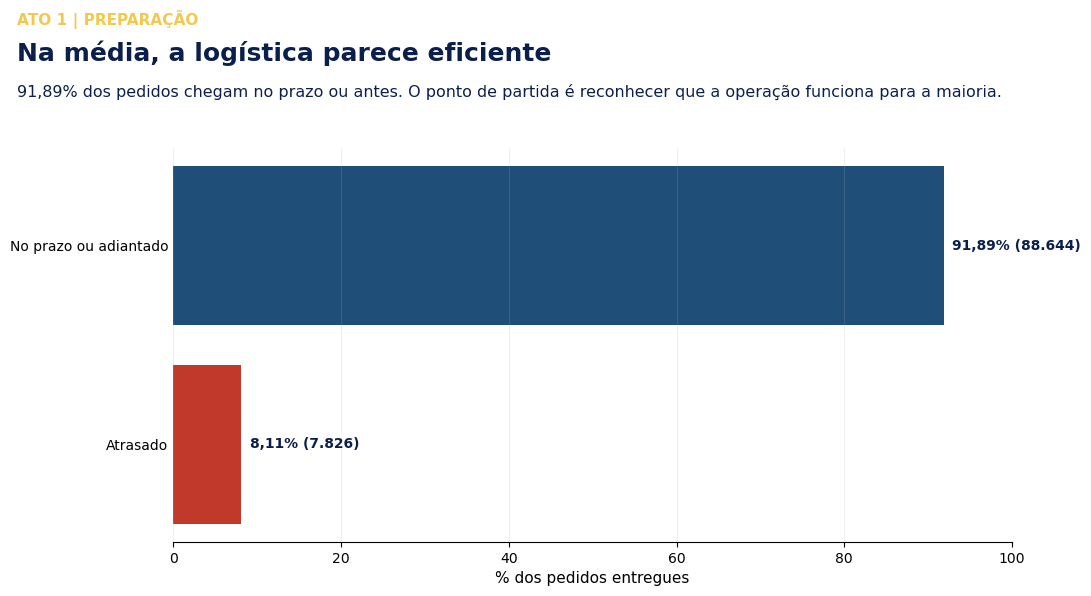

In [72]:
grafico_status = status_entrega.sort_values('porcentagem_pedidos')
cores = [VERMELHO if status == 'Atrasado' else AZUL for status in grafico_status['status_entrega']]

fig, ax = plt.subplots(figsize=(11, 6))
aplicar_storytelling(
    fig,
    'ATO 1 | PREPARAÇÃO',
    'Na média, a logística parece eficiente',
    '91,89% dos pedidos chegam no prazo ou antes. O ponto de partida é reconhecer que a operação funciona para a maioria.'
)

barras = ax.barh(grafico_status['status_entrega'], grafico_status['porcentagem_pedidos'], color=cores)

for barra, pct, qtd in zip(barras, grafico_status['porcentagem_pedidos'], grafico_status['qtd_pedidos']):
    ax.text(pct + 1, barra.get_y() + barra.get_height()/2, f'{fmt_decimal(pct)}% ({fmt_inteiro(qtd)})',
            va='center', color=TEXTO, fontweight='bold')

ax.set_xlabel('% dos pedidos entregues')
ax.set_xlim(0, 100)
limpar_grafico(ax)
plt.tight_layout(rect=[0, 0, 1, 0.78])
plt.savefig(f'{PASTA_GRAFICOS}/01_ato1_preparacao_status_entrega.png', dpi=160, bbox_inches='tight')
plt.show()


### Conflito: o atraso derruba a avaliação

Aqui está o principal gráfico da apresentação: quando a promessa de entrega é quebrada, a nota média cai fortemente.

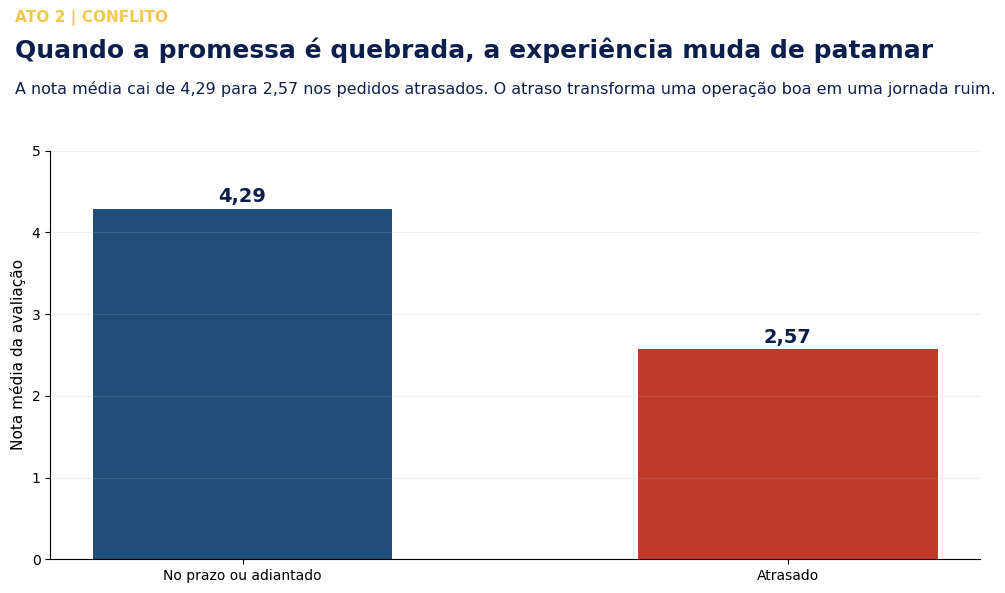

In [73]:
grafico_satisfacao = satisfacao_entrega.copy()
grafico_satisfacao['ordem'] = grafico_satisfacao['status_entrega'].map({'No prazo ou adiantado': 1, 'Atrasado': 2})
grafico_satisfacao = grafico_satisfacao.sort_values('ordem')
cores = [AZUL if status == 'No prazo ou adiantado' else VERMELHO for status in grafico_satisfacao['status_entrega']]

fig, ax = plt.subplots(figsize=(10, 6))
aplicar_storytelling(
    fig,
    'ATO 2 | CONFLITO',
    'Quando a promessa é quebrada, a experiência muda de patamar',
    'A nota média cai de 4,29 para 2,57 nos pedidos atrasados. O atraso transforma uma operação boa em uma jornada ruim.'
)

barras = ax.bar(grafico_satisfacao['status_entrega'], grafico_satisfacao['nota_media'], color=cores, width=0.55)

for barra, valor in zip(barras, grafico_satisfacao['nota_media']):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 0.08, fmt_decimal(valor),
            ha='center', color=TEXTO, fontweight='bold', fontsize=14)

ax.set_ylabel('Nota média da avaliação')
ax.set_ylim(0, 5)
ax.grid(axis='y', alpha=0.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.78])
plt.savefig(f'{PASTA_GRAFICOS}/02_ato2_conflito_queda_nota.png', dpi=160, bbox_inches='tight')
plt.show()


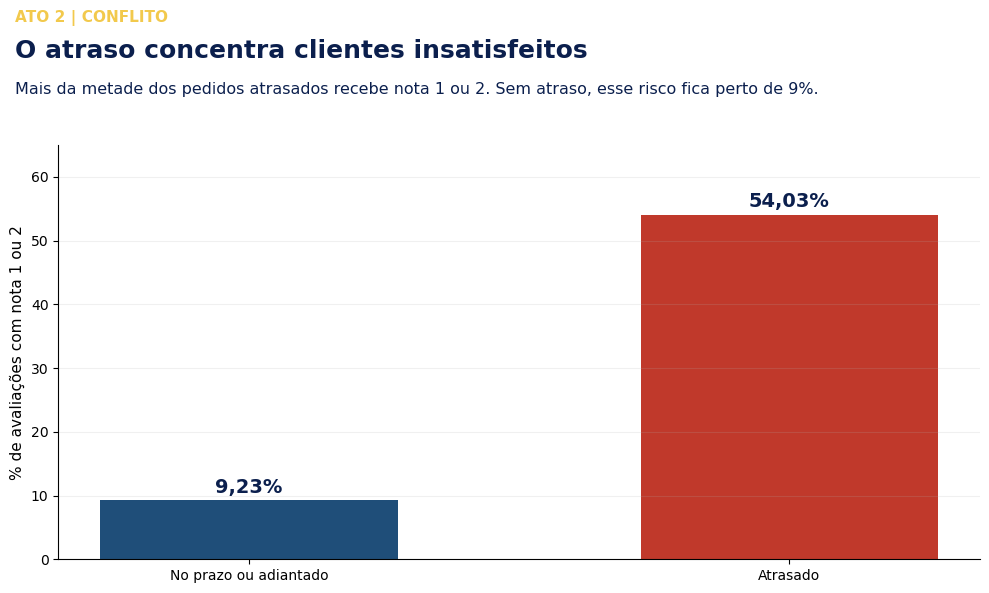

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))
aplicar_storytelling(
    fig,
    'ATO 2 | CONFLITO',
    'O atraso concentra clientes insatisfeitos',
    'Mais da metade dos pedidos atrasados recebe nota 1 ou 2. Sem atraso, esse risco fica perto de 9%.'
)

barras = ax.bar(grafico_satisfacao['status_entrega'], grafico_satisfacao['percentual_notas_ruins'], color=cores, width=0.55)

for barra, valor in zip(barras, grafico_satisfacao['percentual_notas_ruins']):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1.2, f'{fmt_decimal(valor)}%',
            ha='center', color=TEXTO, fontweight='bold', fontsize=14)

ax.set_ylabel('% de avaliações com nota 1 ou 2')
ax.set_ylim(0, 65)
ax.grid(axis='y', alpha=0.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.78])
plt.savefig(f'{PASTA_GRAFICOS}/03_ato2_conflito_notas_ruins.png', dpi=160, bbox_inches='tight')
plt.show()


### Solução: priorizar atrasos antes da zona crítica

Este gráfico ajuda a defender uma régua de comunicação: atrasos maiores exigem tratamento mais forte e mais rápido.

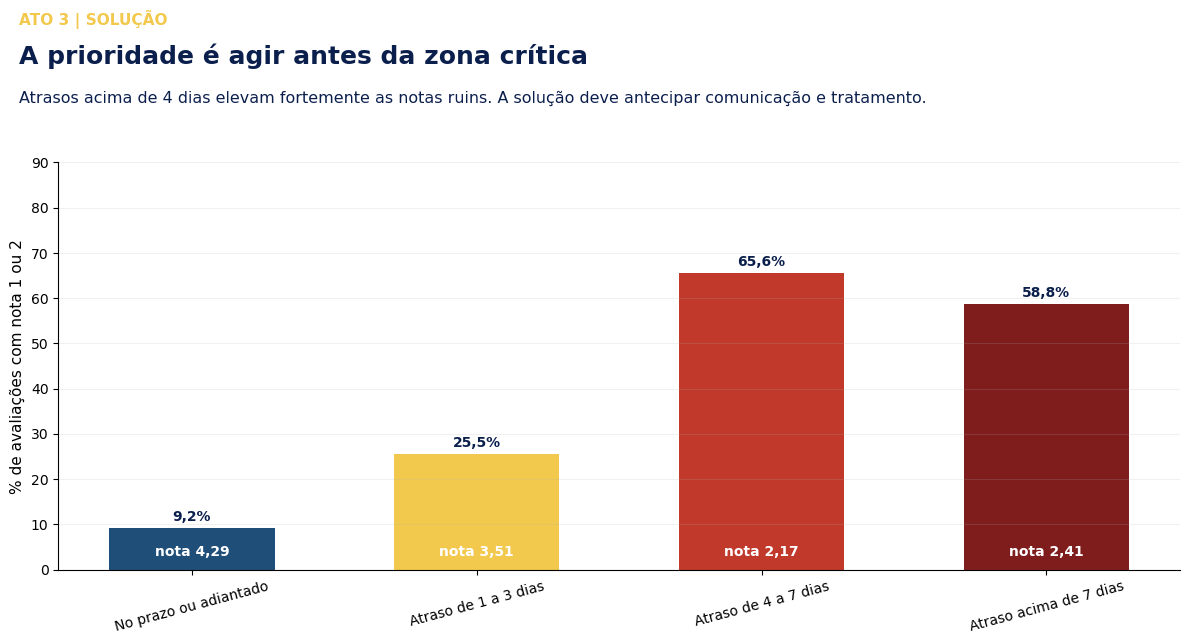

In [75]:
ordem_faixas = [
    'No prazo ou adiantado',
    'Atraso de 1 a 3 dias',
    'Atraso de 4 a 7 dias',
    'Atraso acima de 7 dias'
]
grafico_faixa = faixa_atraso.copy()
if 'percentual_notas_ruins' not in grafico_faixa.columns and 'porcentagem_notas_ruins' in grafico_faixa.columns:
    grafico_faixa = grafico_faixa.rename(columns={'porcentagem_notas_ruins': 'percentual_notas_ruins'})

grafico_faixa['faixa_atraso'] = pd.Categorical(grafico_faixa['faixa_atraso'], categories=ordem_faixas, ordered=True)
grafico_faixa = grafico_faixa.sort_values('faixa_atraso')
cores = [AZUL, AMARELO, VERMELHO, '#7f1d1d']

fig, ax = plt.subplots(figsize=(12, 6.5))
aplicar_storytelling(
    fig,
    'ATO 3 | SOLUÇÃO',
    'A prioridade é agir antes da zona crítica',
    'Atrasos acima de 4 dias elevam fortemente as notas ruins. A solução deve antecipar comunicação e tratamento.'
)

barras = ax.bar(grafico_faixa['faixa_atraso'].astype(str), grafico_faixa['percentual_notas_ruins'], color=cores, width=0.58)

for barra, ruim, nota in zip(barras, grafico_faixa['percentual_notas_ruins'], grafico_faixa['nota_media']):
    ax.text(barra.get_x() + barra.get_width()/2, ruim + 1.5, f'{fmt_decimal(ruim, 1)}%',
            ha='center', color=TEXTO, fontweight='bold')
    ax.text(barra.get_x() + barra.get_width()/2, 3, f'nota {fmt_decimal(nota)}',
            ha='center', color='white', fontweight='bold')

ax.set_ylabel('% de avaliações com nota 1 ou 2')
ax.set_ylim(0, 90)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.78])
plt.savefig(f'{PASTA_GRAFICOS}/04_ato3_solucao_faixas_atraso.png', dpi=160, bbox_inches='tight')
plt.show()


### Onde começar: estados com maior percentual de atraso

Este gráfico fecha a análise com foco de ação: começar pelos estados com maior percentual de atraso e volume mínimo relevante.

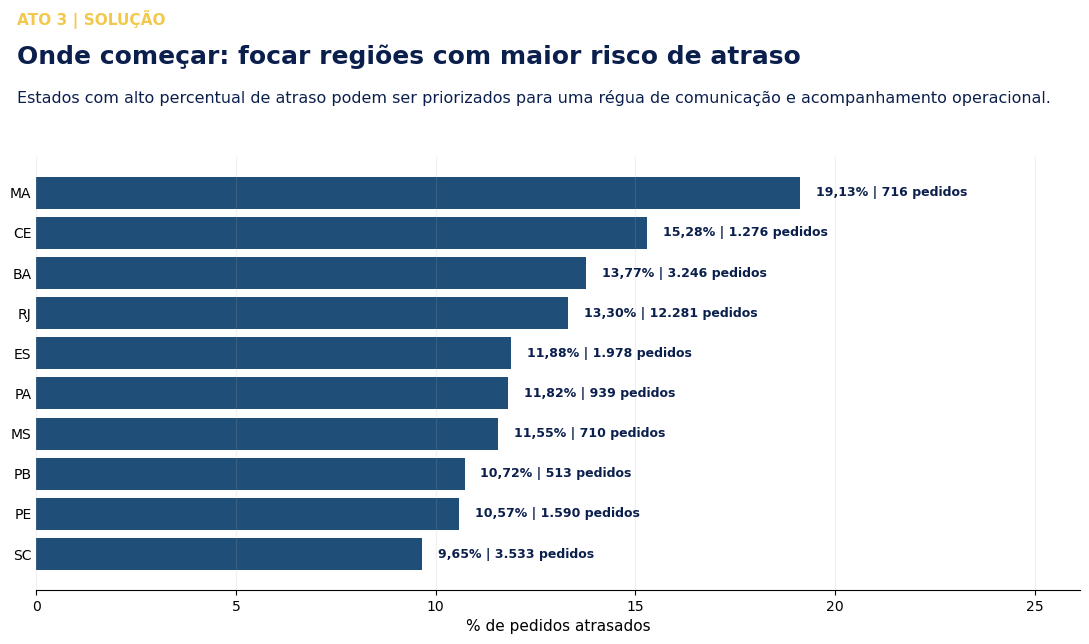

In [76]:
grafico_estado = estado_media.sort_values('pct_atraso', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(11, 6.5))
aplicar_storytelling(
    fig,
    'ATO 3 | SOLUÇÃO',
    'Onde começar: focar regiões com maior risco de atraso',
    'Estados com alto percentual de atraso podem ser priorizados para uma régua de comunicação e acompanhamento operacional.'
)

barras = ax.barh(grafico_estado['estado'], grafico_estado['pct_atraso'], color=AZUL)

for barra, pct, qtd in zip(barras, grafico_estado['pct_atraso'], grafico_estado['qtd_pedidos']):
    ax.text(pct + 0.4, barra.get_y() + barra.get_height()/2, f'{fmt_decimal(pct)}% | {fmt_inteiro(qtd)} pedidos',
            va='center', color=TEXTO, fontweight='bold', fontsize=9)

ax.set_xlabel('% de pedidos atrasados')
ax.set_xlim(0, grafico_estado['pct_atraso'].max() + 7)
limpar_grafico(ax)
plt.tight_layout(rect=[0, 0, 1, 0.78])
plt.savefig(f'{PASTA_GRAFICOS}/05_ato3_solucao_estados_prioritarios.png', dpi=160, bbox_inches='tight')
plt.show()
